# Spectral Clustering analysis

Instructions:
1. Try multiple graph constructions. kNN graphs with different kk
k values often give different clusterings. If your results are stable across k=5,10,15k = 5, 10, 15
k=5,10,15, you can trust them; if they wobble dramatically, the structure is fragile.
2. Use the normalized Laplacian. The unnormalized version is sensitive to degree variation. Normalized (especially the symmetric version LsymL_{\text{sym}}
Lsym​) is generally better-behaved on real data.
3. Inspect the eigengap. Plot the sorted eigenvalues of LL
L. A clear gap between λk\lambda_k
λk​ and λk+1\lambda_{k+1}
λk+1​ suggests kk
k clusters. No gap means no clean cluster structure (which is itself informative).
4. Run k-means many times with different initializations and take the most consistent result. The eigendecomposition is deterministic but the final k-means step isn't.
5. Visualize the embedding. Plot the 2D or 3D embedding (rows of UU
U for the smallest 2-3 nontrivial eigenvectors). If clusters are visually obvious in this space, k-means will find them easily. If they're not, you'll know before you even run k-means.


## Pipeline overview

The data is a `7 × 72` connectivity matrix where each column is a cortical region's connectivity fingerprint to the 7 hippocampal subregions. The cosine similarity matrix $C$ (`72 × 72`) tells us how similar each cortical region's connectivity *profile* is to every other's. Magnitude is normalized away by cosine, so two regions that both prefer anterior > posterior hippocampus look similar regardless of how strongly each one connects overall.

**The big question:** how does cortex partition into groups whose hippocampal profiles are mutually similar?

**Spectral clustering's answer, in four moves:**

1. **Graph construction** — turn $C$ into a sparse kNN graph so each cortical region links only to its closest neighbors in profile space. This denoises and emphasizes local structure.
2. **Graph Laplacian** — encode the graph as a matrix $L$ whose eigenvectors expose the natural "cuts" in the graph. Disconnected components show up as zero eigenvalues; near-disconnected components show up as small ones.
3. **Spectral embedding** — project each region into a low-dimensional space using the *smallest* eigenvectors of $L$. In this transformed space, clusters that were curved or irregular in the original similarity space become convex blobs.
4. **k-means in embedding space** — run vanilla k-means on the embedded points to recover labels.

**Two cosine matrices** are analyzed in parallel:
- `cosine_df_from_shared` — cortex similarity based on connections *from* hippocampus to cortex
- `cosine_df_to_shared` — cortex similarity based on connections *to* hippocampus from cortex

These can give different cluster structures, reflecting asymmetry between hippocampal afferents and efferents.

**Key constraint to remember throughout:** the rank of $C$ is bounded by 7 (the feature dimension). At most 7 of $C$'s 72 eigenvalues are nonzero, so we cannot meaningfully extract more than ~7 clusters or gradients. This bound shapes everything downstream.

In [1]:
import numpy as np
import pandas as pd 
from helpers import get_feature_vectors_shared_hpc, get_correlation_matrix

## Step 1 — Load feature vectors and build cosine similarity matrices

`get_feature_vectors_shared_hpc()` returns two `7 × 72` connectivity matrices: one for the from-shared direction and one for the to-shared direction. Each column is a cortical region's 7-dimensional hippocampal fingerprint.

`get_correlation_matrix(...)` computes pairwise cosine similarity between all pairs of columns, producing a `72 × 72` symmetric matrix with 1's on the diagonal. Entry $(i, j)$ tells you how aligned regions $i$ and $j$ are in their hippocampal preference profile, ignoring magnitude.

These two matrices are the inputs to everything downstream. We never go back to the original feature vectors after this point — all the spectral analysis operates on $C$.

This is the lofeature vectors building siilarity 

In [5]:
df_avg_to_shared, df_avg_from_shared = get_feature_vectors_shared_hpc()

cosine_df_from_shared = get_correlation_matrix(df_avg_from_shared)

cosine_df_to_shared = get_correlation_matrix(df_avg_to_shared)

## Step 2 — Clustering toolkit

A few additional libraries are needed beyond pandas/numpy:

- **`scipy.linalg.eigh`** — eigendecomposition for symmetric matrices. The Laplacian is symmetric, so `eigh` is faster and more numerically stable than the general-purpose `eig`. It returns eigenvalues already sorted in ascending order.
- **`sklearn.cluster.KMeans`** — runs the final k-means partitioning step in spectral embedding space.
- **`sklearn.preprocessing.normalize`** — row-normalizes the spectral embedding matrix. This is the Ng–Jordan–Weiss variant of spectral clustering: each region's embedding vector is rescaled to unit length so that k-means clusters by *direction* rather than direction-plus-magnitude.
- **`silhouette_score`** — quantifies how well-separated clusters are using a precomputed dissimilarity matrix.
- **`adjusted_rand_score`** — measures agreement between two clusterings (chance-corrected). Used for stability analysis.
- **`itertools.combinations`** — helper for generating pairs of kNN values to compare.

In [2]:
import matplotlib.pyplot as plt
from itertools import combinations
from scipy.linalg import eigh
from sklearn.cluster import KMeans
from sklearn.preprocessing import normalize
from sklearn.metrics import silhouette_score, adjusted_rand_score

## Step 3 — Building blocks: kNN graph, Laplacian, spectral embedding

Three helpers do the spectral-clustering heavy lifting.

### `build_knn_affinity(sim_matrix, k)`

Converts the dense `72 × 72` cosine matrix into a sparse, symmetric **k-nearest-neighbors graph**:

1. Zero out the diagonal so a region isn't its own neighbor.
2. For each row $i$, keep only the $k$ largest similarities (those are the $k$ most-similar regions to $i$); zero out everything else.
3. Symmetrize using `max(A, A.T)` — region $i$ and $j$ are connected if either side picked the other.
4. Shift any negatives up to zero so the affinity is non-negative (the Laplacian construction below requires this).

**Why sparsify?** The full cosine matrix is dense, so every region is "weakly similar" to every other. That weak background similarity is mostly noise and tends to wash out real cluster structure. Restricting attention to the $k$ closest neighbors emphasizes local geometry — which is what the cluster structure lives in.

### `normalized_laplacian(A)`

Computes the **symmetric normalized Laplacian**:
$$L_{\text{sym}} = I - D^{-1/2} A D^{-1/2}$$
where $D$ is the diagonal degree matrix ($D_{ii} = \sum_j A_{ij}$, the total connection weight at node $i$).

**Why normalized?** The unnormalized Laplacian $L = D - A$ is biased toward equal-size clusters and is highly sensitive to degree variation: a high-degree hub gets disproportionate influence. The symmetric normalized version corrects for this, and it's what most theoretical spectral clustering results are stated for.

**What does $L$ encode?** For any function $f$ assigning a value to each node, the quadratic form $f^\top L f$ measures how much $f$ varies across edges (weighted by edge strength). Small values of $f^\top L f$ mean $f$ is "smooth" — assigns similar values to strongly-connected nodes. The eigenvectors with the smallest eigenvalues are the smoothest possible functions on the graph; they reveal the natural cuts.

### `spectral_embed(sim_matrix, k_neighbors, n_components)`

Chains the two helpers above and runs `eigh` on the resulting Laplacian. Returns:
- the full sorted eigenvalue vector (used for eigengap analysis)
- the `n_components` eigenvectors corresponding to the smallest eigenvalues — these form the spectral embedding

The smallest Laplacian eigenvalue is always 0, and its eigenvector is constant. The next several eigenvectors are the smoothest non-constant functions on the graph; their entries assign each region a coordinate along an axis that respects the graph's connectivity structure.

In [3]:
def build_knn_affinity(sim_matrix, k):
    """Build a symmetric kNN affinity matrix from a cosine similarity matrix."""
    A = sim_matrix.values.copy().astype(float)
    np.fill_diagonal(A, 0)
    knn = np.zeros_like(A)
    for i in range(len(A)):
        top_k = np.argsort(A[i])[-k:]
        knn[i, top_k] = A[i, top_k]
    knn = np.maximum(knn, knn.T)
    if knn.min() < 0:
        knn -= knn.min()
    return knn


def normalized_laplacian(A):
    """Symmetric normalized Laplacian: L_sym = I - D^{-1/2} A D^{-1/2}."""
    d = A.sum(axis=1)
    d_inv_sqrt = np.where(d > 0, 1.0 / np.sqrt(d), 0.0)
    D_inv_sqrt = np.diag(d_inv_sqrt)
    return np.eye(len(A)) - D_inv_sqrt @ A @ D_inv_sqrt


def spectral_embed(sim_matrix, k_neighbors, n_components):
    """Return sorted eigenvalues and the n_components smallest eigenvectors."""
    A = build_knn_affinity(sim_matrix, k_neighbors)
    L = normalized_laplacian(A)
    eigenvalues, eigenvectors = eigh(L)
    return eigenvalues, eigenvectors[:, :n_components]

## Step 4 — Eigengap analysis: how many clusters does the data support?

Before we run any clustering, we want to know whether the data even has cluster structure, and if so, how many clusters. Two complementary plots give that information.

### Plot 1: eigenvalues of $C$ itself

Because the underlying fingerprints live in 7-dimensional hippocampal space, the cosine matrix $C$ has rank at most 7. That means at most 7 of $C$'s 72 eigenvalues are nonzero — the rest are exactly zero, an artifact of the matrix being padded out to `72 × 72`.

This plot shows the top 15 eigenvalues of $C$, with a red line marking index 7.5. **Expect a sharp drop to zero after index 7**: if eigenvalue 8 onward is essentially zero, the rank-7 ceiling is confirmed and we know there are at most 7 axes of meaningful variation.

The shape of the *first* 7 eigenvalues also matters. A sharp drop after, say, eigenvalue 3 means most of the variance is in the first 3 axes — pointing toward a 3-component / 3-cluster story. A gentle decay across all 7 means the variance is spread out (a smooth gradient with no clean clusters).

### Plot 2: Laplacian eigengap for k_nn ∈ {5, 10, 15}

Spectral clustering's number-of-clusters heuristic: **plot the sorted Laplacian eigenvalues. A clear jump between $\lambda_k$ and $\lambda_{k+1}$ suggests $k$ clusters.**

Why: in the idealized case where the graph splits cleanly into $k$ disconnected components, $L$ has exactly $k$ zero eigenvalues (one per component) and the next eigenvalue is strictly positive. In real data the components are nearly-but-not-quite disconnected, so the first $k$ eigenvalues are *small* and there's a visible gap before larger ones.

The red dashed line marks the largest gap in each subplot — that's the eigengap heuristic's vote for `n_clusters`. We compute this for three different kNN graph constructions to check robustness:
- If the eigengap suggests the same $k$ across `k_nn = 5, 10, 15`, the cluster structure is robust to graph construction.
- If the gap location wobbles with `k_nn`, the structure is fragile and we shouldn't trust any single answer.
- If there's no clear gap at all, the data is gradient-like rather than cluster-like — also a valid scientific finding.

We restrict to the first 10 Laplacian eigenvalues because anything past the rank-7 ceiling on $C$ is unlikely to carry useful structure.

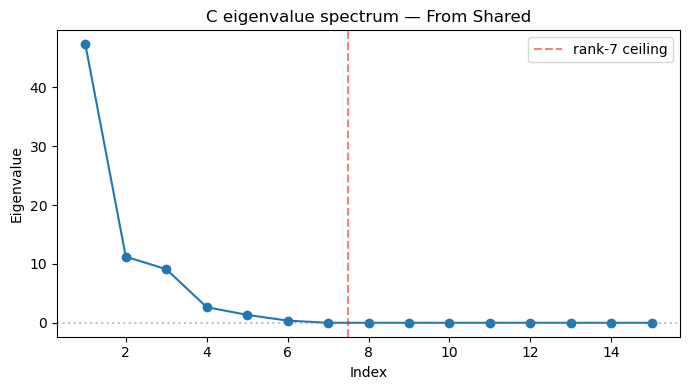

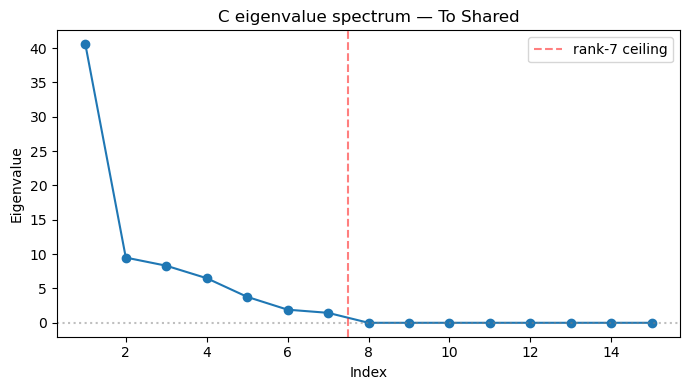

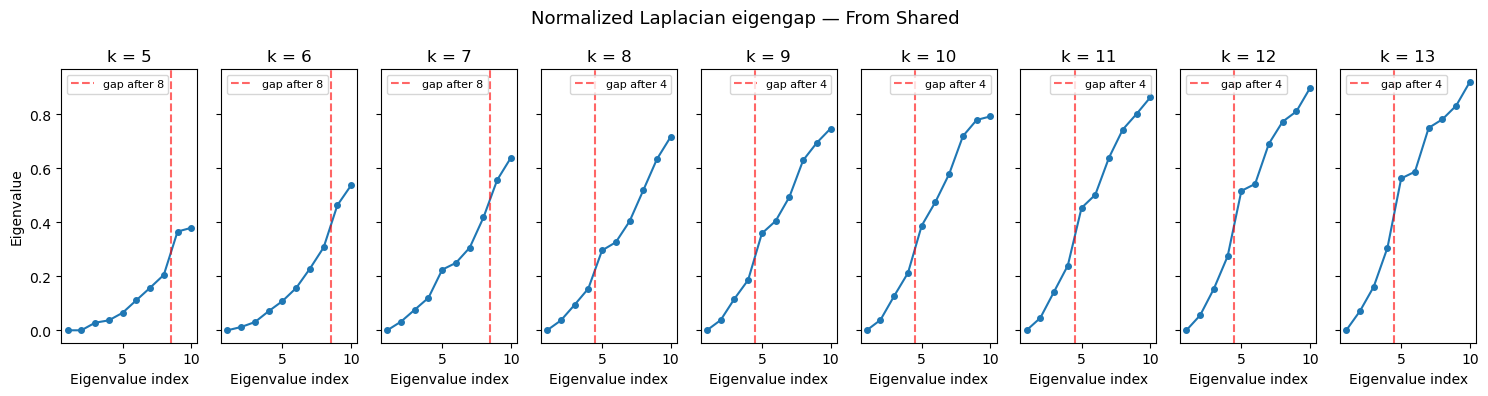

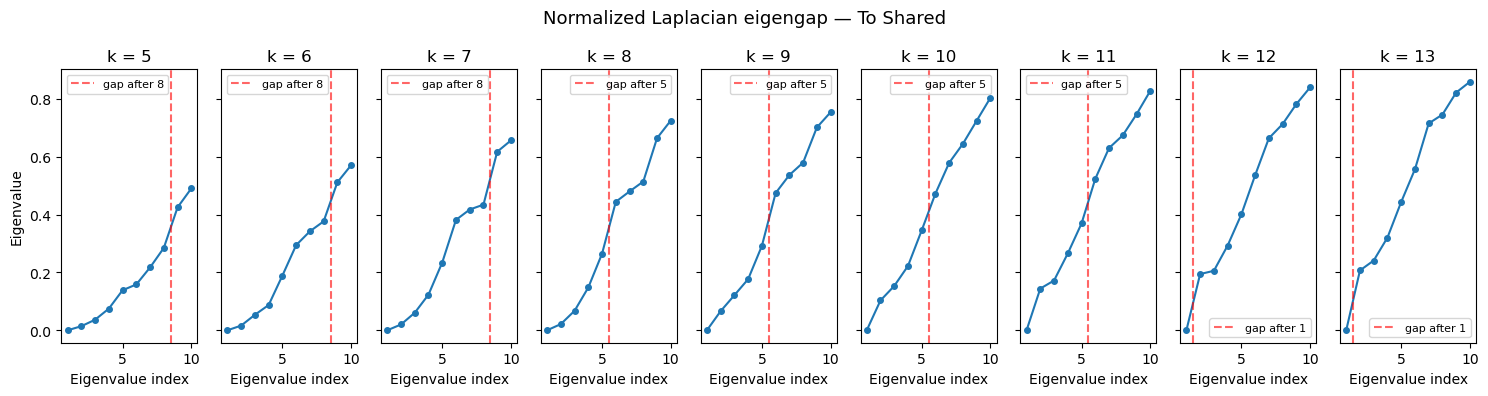

In [36]:
# The data is rank 7 (7-dim hippocampal fingerprints), so C has at most 7
# nonzero eigenvalues — making this a clean object to inspect.
def plot_C_spectrum(sim_matrix, title, n_eigs=15):
    eigenvalues = np.sort(np.linalg.eigvalsh(sim_matrix.values))[::-1]
    fig, ax = plt.subplots(figsize=(7, 4))
    ax.plot(range(1, n_eigs + 1), eigenvalues[:n_eigs], 'o-')
    ax.axhline(0, color='grey', linestyle=':', alpha=0.5)
    ax.axvline(7.5, color='r', linestyle='--', alpha=0.5, label='rank-7 ceiling')
    ax.set_title(f'C eigenvalue spectrum — {title}')
    ax.set_xlabel('Index')
    ax.set_ylabel('Eigenvalue')
    ax.legend()
    plt.tight_layout()
    plt.show()


def plot_laplacian_eigengap(sim_matrix, title, k_values=(5, 10, 15), n_eigs=10):
    fig, axes = plt.subplots(1, len(k_values), figsize=(15, 4), sharey=True)
    for ax, k in zip(axes, k_values):
        eigenvalues, _ = spectral_embed(sim_matrix, k, n_eigs)
        gaps = np.diff(eigenvalues[:n_eigs])
        best_gap_idx = int(np.argmax(gaps))
        ax.plot(range(1, n_eigs + 1), eigenvalues[:n_eigs], 'o-', markersize=4)
        ax.axvline(best_gap_idx + 1.5, color='r', linestyle='--', alpha=0.6,
                   label=f'gap after {best_gap_idx + 1}')
        ax.set_title(f'k = {k}')
        ax.set_xlabel('Eigenvalue index')
        ax.legend(fontsize=8)
    axes[0].set_ylabel('Eigenvalue')
    fig.suptitle(f'Normalized Laplacian eigengap — {title}', fontsize=13)
    plt.tight_layout()
    plt.show()

plot_C_spectrum(cosine_df_from_shared, 'From Shared')
plot_C_spectrum(cosine_df_to_shared,   'To Shared')

plot_laplacian_eigengap(cosine_df_from_shared, 'From Shared', k_values=range(5,14), n_eigs=10)
plot_laplacian_eigengap(cosine_df_to_shared,   'To Shared', k_values=range(5,14), n_eigs=10)

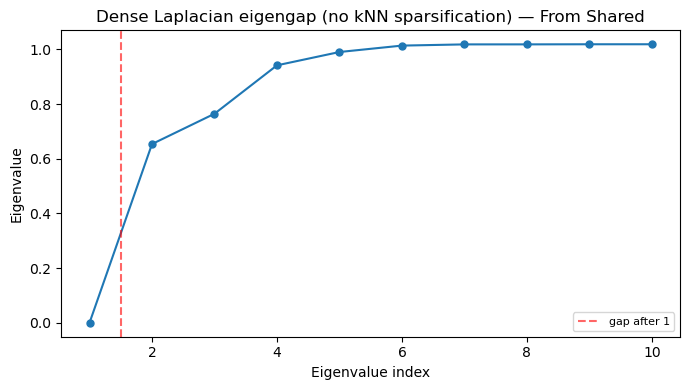

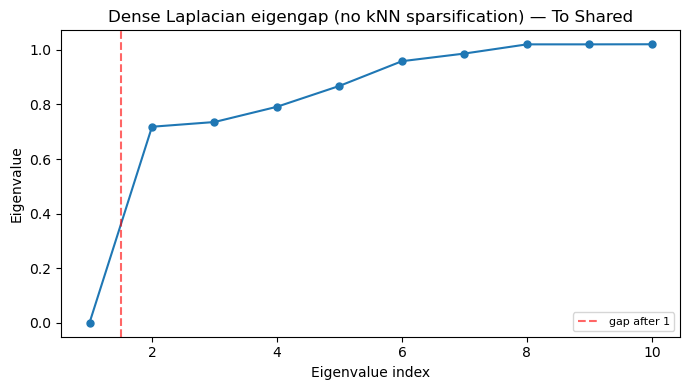

In [29]:
# Eigengap on the dense (un-sparsified) cosine matrix — uses C directly as the
# affinity, with the diagonal zeroed and any negatives clipped to 0. This is the
# kNN→∞ limit of the analysis above, useful as a baseline for comparing against
# the sparsified versions.
def plot_dense_laplacian_eigengap(sim_matrix, title, n_eigs=10):
    A = sim_matrix.values.copy().astype(float)
    np.fill_diagonal(A, 0)
    A = np.clip(A, 0, None)
    L = normalized_laplacian(A)
    eigenvalues = np.sort(np.linalg.eigvalsh(L))
    gaps = np.diff(eigenvalues[:n_eigs])
    best_gap_idx = int(np.argmax(gaps))

    fig, ax = plt.subplots(figsize=(7, 4))
    ax.plot(range(1, n_eigs + 1), eigenvalues[:n_eigs], 'o-', markersize=5)
    ax.axvline(best_gap_idx + 1.5, color='r', linestyle='--', alpha=0.6,
               label=f'gap after {best_gap_idx + 1}')
    ax.set_xlabel('Eigenvalue index')
    ax.set_ylabel('Eigenvalue')
    ax.set_title(f'Dense Laplacian eigengap (no kNN sparsification) — {title}')
    ax.legend(fontsize=8)
    plt.tight_layout()
    plt.show()

plot_dense_laplacian_eigengap(cosine_df_from_shared, 'From Shared')
plot_dense_laplacian_eigengap(cosine_df_to_shared,   'To Shared')

## Step 5 — The full spectral clustering function

`spectral_cluster(sim_matrix, k_neighbors, n_clusters, n_init)` packages the full pipeline into one call:

1. **Spectral embedding.** Compute the `n_clusters` smallest eigenvectors of the normalized Laplacian. Stack them as columns of a `72 × n_clusters` matrix $U$. Each row is a region's coordinate in the spectral embedding space.
2. **Row normalization.** Project each row of $U$ onto the unit sphere. This is the Ng–Jordan–Weiss step — it stops k-means from getting confused by length variation between rows and makes the clustering depend on direction only.
3. **k-means with random restarts.** Run k-means `n_init=50` times, each with a fresh random initialization. Keep the run with the lowest within-cluster sum of squares (inertia). Return its labels.

**Why so many restarts?** The eigendecomposition is deterministic — feeding the same affinity matrix in always gives the same embedding. But the final k-means step is non-convex: with random initialization it can converge to a local optimum that's worse than the global one. Running 50 restarts and keeping the best result vastly reduces the chance of returning a bad local optimum.

The function also returns `U_norm` so we can visualize the embedding directly later.

In [8]:
def spectral_cluster(sim_matrix, k_neighbors, n_clusters, n_init=50):
    """Spectral clustering with n_init k-means runs; returns best labels and row-normalized embedding."""
    _, U = spectral_embed(sim_matrix, k_neighbors, n_clusters)
    U_norm = normalize(U, norm='l2')
    best_labels, best_inertia = None, np.inf
    for seed in range(n_init):
        km = KMeans(n_clusters=n_clusters, init='random', n_init=1, random_state=seed)
        km.fit(U_norm)
        if km.inertia_ < best_inertia:
            best_inertia = km.inertia_
            best_labels = km.labels_
    return best_labels, U_norm

## Step 6 — Silhouette score sweep

The eigengap is one signal. **Silhouette score** is a second, complementary one — it judges how well-separated clusters actually are, rather than just inferring it from the spectrum.

For each candidate `n_clusters` from 2 to 7 (capped at 7 because of the rank ceiling), and for each of the three kNN graphs (`k_nn = 5, 10, 15`), we run spectral clustering and compute the silhouette score using $1 - C$ as the precomputed dissimilarity matrix.

### How silhouette is computed

For each region $i$:
- $a(i)$ = mean dissimilarity to other regions in $i$'s own cluster
- $b(i)$ = mean dissimilarity to regions in the *next nearest* cluster
- silhouette$(i) = (b(i) - a(i)) / \max(a(i), b(i))$

The reported score is the mean across all regions:
- **+1**: tight, well-separated clusters
- **0**: overlapping clusters
- **−1**: misclassified

### Reading the plot

Three things matter:

1. **Where the peak lies** — this is silhouette's vote for `n_clusters`.
2. **Whether the peak agrees across `k_nn` values** — consistency means trustworthy.
3. **Absolute height** — silhouettes much below 0.2 typically signal weak cluster structure (e.g., a smooth gradient that's been forced into discrete bins).

If the silhouette peak agrees with the eigengap heuristic from step 4, that's strong evidence we've found a real `n_clusters`.

/opt/anaconda3/envs/br2f/lib/python3.12/site-packages/sklearn/base.py:1473: ConvergenceWarning: Number of distinct clusters (10) found smaller than n_clusters (11). Possibly due to duplicate points in X.
  return fit_method(estimator, *args, **kwargs)


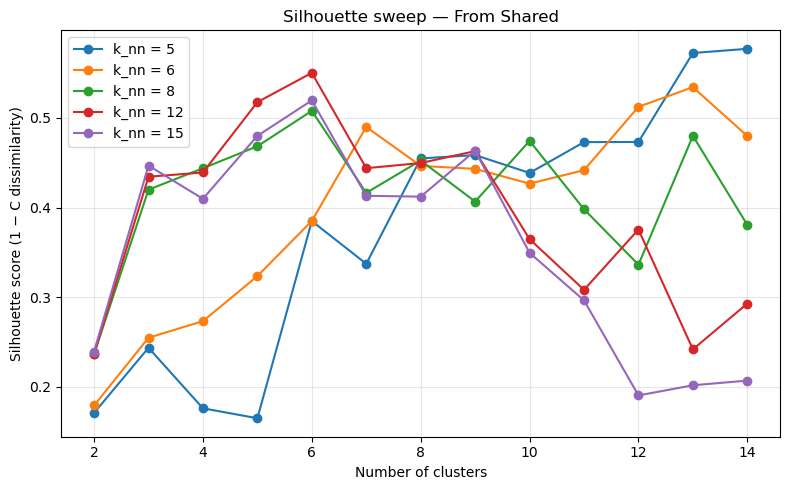

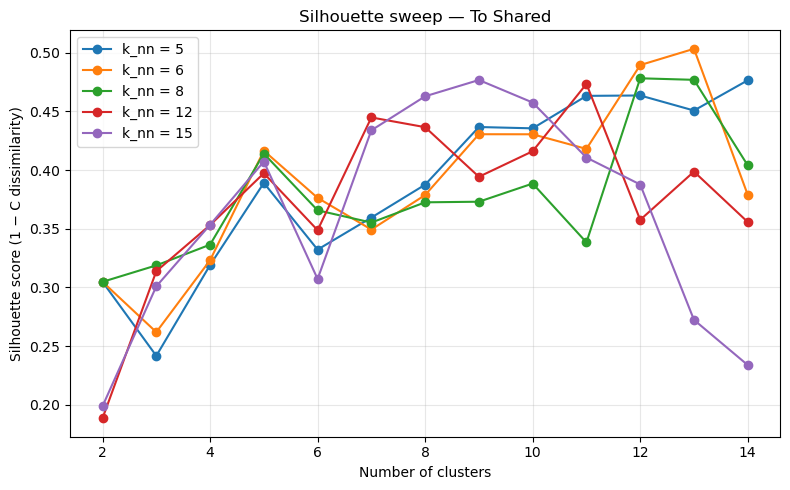

Number of clusters with the highest average silhouette score - efferent: 6
Number of clusters with the highest average silhouette score - afferent: 12


In [35]:
# Silhouette sweep over n_clusters = 2..7 (rank-7 ceiling on meaningful clusters),
# for each candidate kNN graph. Uses 1 - C as the precomputed dissimilarity.
def silhouette_sweep(sim_matrix, k_neighbors_list=(5,6,8, 12, 15), n_clusters_range=range(2, 15), n_init=20):
    dissim = 1 - sim_matrix.values
    np.fill_diagonal(dissim, 0)
    dissim = np.clip(dissim, 0, None)
    results = {}
    for k_nn in k_neighbors_list:
        scores = []
        for n_c in n_clusters_range:
            labels, _ = spectral_cluster(sim_matrix, k_nn, n_c, n_init=n_init)
            scores.append(silhouette_score(dissim, labels, metric='precomputed'))
        results[k_nn] = scores
    return results, list(n_clusters_range)


def plot_silhouette_sweep(sim_matrix, title):
    results, n_clusters_range = silhouette_sweep(sim_matrix)
    fig, ax = plt.subplots(figsize=(8, 5))
    for k_nn, scores in results.items():
        ax.plot(n_clusters_range, scores, 'o-', label=f'k_nn = {k_nn}')
    ax.set_xlabel('Number of clusters')
    ax.set_ylabel('Silhouette score (1 − C dissimilarity)')
    ax.set_title(f'Silhouette sweep — {title}')
    ax.legend()
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()
    return results

n_clusters_range = range(2,15)

silhouette_from = plot_silhouette_sweep(cosine_df_from_shared, 'From Shared')
silhouette_to   = plot_silhouette_sweep(cosine_df_to_shared,   'To Shared')

# set up for creating the sillhouette scores dataframe - from
silhouette_from_keys = np.array([key for key in silhouette_from])
silhouette_from_array = []
for k_nn in silhouette_from:
    silhouette_from_array.append(silhouette_from[k_nn])

silhouette_from_df = pd.DataFrame(
    data=silhouette_from_array,
    index = silhouette_from_keys,
    columns=n_clusters_range,
)

# setup for creating the silhouette scores dataframe - to
silhouette_to_keys = np.array([key for key in silhouette_to])
silhouette_to_array = []
for k_nn in silhouette_to:
    silhouette_to_array.append(silhouette_to[k_nn])

silhouette_to_df = pd.DataFrame(
    data=silhouette_to_array,
    index = silhouette_to_keys,
    columns=n_clusters_range,
)

# now get the average silhouette score for each cluster
silhouette_from_df.loc['average',:] = silhouette_from_df.mean(axis=0)
max_score_from = silhouette_from_df.loc['average'].idxmax()
print(f'Number of clusters with the highest average silhouette score - efferent: {max_score_from}')

silhouette_to_df.loc['average',:] = silhouette_to_df.mean(axis=0)
max_score_to = silhouette_to_df.loc['average'].idxmax()
print(f'Number of clusters with the highest average silhouette score - afferent: {max_score_to}')

## Step 7 — Stability of cluster assignments across graph constructions

Silhouette tells us *how well separated* clusters are at each `n_clusters`. Stability tells us *how consistent the actual cluster assignments* are when we change the graph construction.

For each `n_clusters` (2 through 7), we run spectral clustering three times — once with each `k_nn` ∈ {5, 10, 15} — and compute the **Adjusted Rand Index (ARI)** between every pair of label sets.

### ARI in plain terms

ARI compares two clusterings of the same set of items and asks: do they agree on which pairs of items belong together?
- **ARI = 1**: the two clusterings are identical (up to permutation of cluster labels — labels are arbitrary names).
- **ARI ≈ 0**: agreement is no better than random chance.
- **ARI < 0**: worse than chance (rare).

The "adjusted" part subtracts off the agreement you'd get from random labelings of matching cluster sizes, so ARI doesn't give credit for trivial agreement.

### Reading the plot

The plot shows ARI curves vs. `n_clusters` for each pair of `k_nn` values. The interpretation:

- **Flat and near 1** across the range: the cluster structure is genuinely there in the data, not an artifact of a particular graph construction. **This is what you want.**
- **Drops at large `n_clusters`**: at some point you've over-partitioned. The first few clusters are real, but past that the additional splits are noise-driven and disagree across graph constructions.
- **Low everywhere**: the cluster structure is fragile. Probably the data is gradient-like, and any clustering is just slicing arbitrary chunks out of a continuum.

The grey reference line at ARI = 1 is the "ideal" — perfect agreement.

### Why this is the strongest single test

Silhouette can be fooled by a smooth gradient that happens to have a peak at one `n_clusters`. Eigengap can be fooled by a particular `k_nn` choice. But for ARI to stay high across both `n_clusters` and `k_nn`, the data has to actually contain blocks of regions that group together regardless of graph-construction details. That's the property a real cluster structure should have.

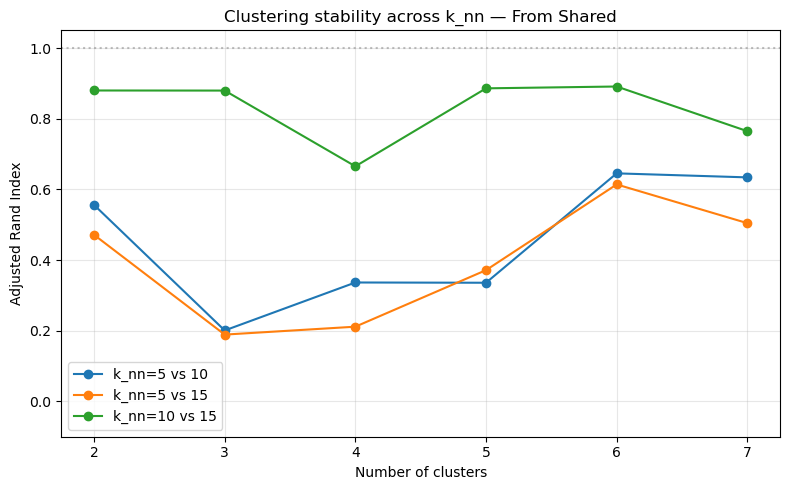

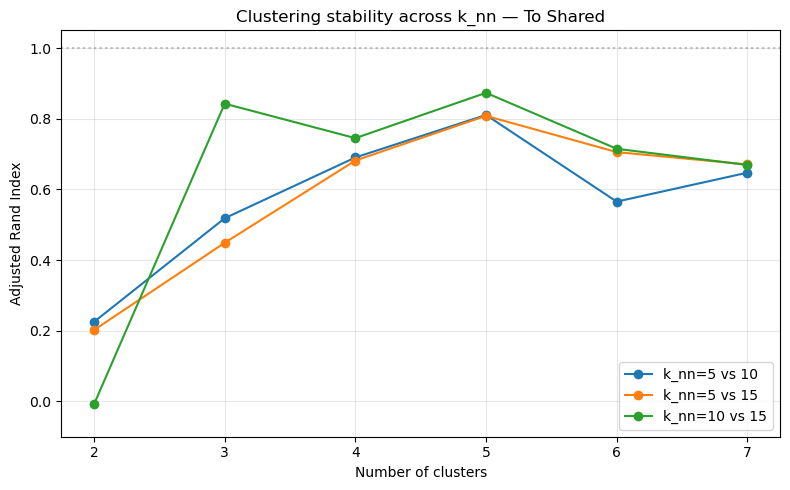

In [37]:
# Stability check: pairwise ARI between clusterings produced under different kNN graphs.
# A high, flat curve across n_clusters indicates that the structure isn't fragile to k_nn choice.
def stability_across_knn(sim_matrix, n_clusters, k_neighbors_list=(5, 10, 15), n_init=20):
    label_sets = {k: spectral_cluster(sim_matrix, k, n_clusters, n_init=n_init)[0]
                  for k in k_neighbors_list}
    return {(a, b): adjusted_rand_score(label_sets[a], label_sets[b])
            for a, b in combinations(k_neighbors_list, 2)}


def plot_stability(sim_matrix, title, n_clusters_range=range(2, 8)):
    pair_scores = {}
    for n_c in n_clusters_range:
        ari = stability_across_knn(sim_matrix, n_c)
        for pair, score in ari.items():
            pair_scores.setdefault(pair, []).append(score)

    fig, ax = plt.subplots(figsize=(8, 5))
    for pair, scores in pair_scores.items():
        ax.plot(list(n_clusters_range), scores, 'o-', label=f'k_nn={pair[0]} vs {pair[1]}')
    ax.set_xlabel('Number of clusters')
    ax.set_ylabel('Adjusted Rand Index')
    ax.set_title(f'Clustering stability across k_nn — {title}')
    ax.set_ylim(-0.1, 1.05)
    ax.axhline(1.0, color='grey', linestyle=':', alpha=0.5)
    ax.legend()
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

plot_stability(cosine_df_from_shared, 'From Shared')
plot_stability(cosine_df_to_shared,   'To Shared')

## Step 8 — Final cluster assignments

Pick `N_CLUSTERS` and `K_NEIGHBORS` based on **convergent evidence** from steps 4–7. The three diagnostics each suggest an answer; trust answers that all three agree on:

| Diagnostic | What it measures | Agreement signal |
|---|---|---|
| C / Laplacian eigengap (step 4) | Spectral structure of the similarity / graph | A clear gap at the same $k$ across all `k_nn` |
| Silhouette sweep (step 6) | How well-separated the clusters are | A clear peak at the same $k$ across all `k_nn` |
| Stability ARI (step 7) | Whether assignments are robust to graph construction | ARI ≈ 1 at the chosen $k$ |

For `K_NEIGHBORS`, pick a value where the eigengap and silhouette are clean. `k_nn = 10` is a reasonable default that doesn't over-localize (small `k`) or wash out structure (large `k`).

The defaults below (`N_CLUSTERS = 5`, `K_NEIGHBORS = 10`) are placeholders — adjust them after inspecting the diagnostics. The cell prints cluster sizes for each matrix; large class imbalance (one cluster swallowing most regions) is a red flag suggesting either over- or under-partitioning.

Note that the from-shared and to-shared matrices may favor different `N_CLUSTERS` values — that's fine and probably interesting. You can run the cell twice with different settings if needed.

In [42]:
# Pick N_CLUSTERS where the eigengap, silhouette peak, and stability ARI agree.
# Bounded above by 7 because of the rank-7 ceiling on C.
N_CLUSTERS_EFFERENT = 3
N_CLUSTERS_AFFERENT = 4
K_NEIGHBORS = 10

labels_from, U_from = spectral_cluster(cosine_df_from_shared, K_NEIGHBORS, N_CLUSTERS_EFFERENT)
labels_to,   U_to   = spectral_cluster(cosine_df_to_shared,   K_NEIGHBORS, N_CLUSTERS_AFFERENT)

print("From Shared — cluster sizes:", dict(zip(*np.unique(labels_from, return_counts=True))))
print("To Shared   — cluster sizes:", dict(zip(*np.unique(labels_to,   return_counts=True))))

From Shared — cluster sizes: {np.int32(0): np.int64(25), np.int32(1): np.int64(32), np.int32(2): np.int64(15)}
To Shared   — cluster sizes: {np.int32(0): np.int64(12), np.int32(1): np.int64(19), np.int32(2): np.int64(19), np.int32(3): np.int64(22)}


## Step 9 — Visualize the spectral embedding

The spectral embedding `U_norm` is a `72 × N_CLUSTERS` matrix where each row is one cortical region's coordinate in the low-dimensional space spectral clustering operates in. This space is exactly where the cluster structure becomes geometrically obvious: in the original similarity matrix, clusters can be curved or irregular, but in the spectral embedding they typically separate into convex blobs.

We plot three pairwise scatterplots — EV2 vs EV3, EV1 vs EV2, and EV1 vs EV3 — colored by cluster label. Each region appears once in each plot, with its color reflecting the assignment from step 8.

### What the eigenvectors mean

- **EV1** (the first nontrivial eigenvector) is typically the dominant axis of variation in the graph. For brain connectivity data this often turns out to be a **principal gradient** — for example, an anterior-posterior axis of hippocampal preference, or a sensory-association axis. EV1 is also what the connectivity-gradient literature (Margulies et al.) extracts and interprets.
- **EV2 and EV3** are orthogonal modes of variation, capturing finer structure that EV1 doesn't cover.

So these scatterplots are showing the same kind of low-dimensional embedding that gradient analyses produce — but now with cluster labels overlaid.

### Reading the plots

- **Visible blobs, colored consistently within each blob**: spectral clustering has found real, well-separated structure. This is the success case.
- **Regions clearly separated along an axis but smoothly distributed (forming a band or arc)**: the data has gradient structure, and the cluster boundaries are arbitrary slices through that continuum. The `n_clusters` choice is then somewhat aesthetic; the gradient itself is the real finding.
- **Mixed colors at the boundaries between blobs**: the cluster boundary is fuzzy, meaning some regions sit between clusters or on a transition zone. Often biologically meaningful.
- **Same color spread all over the plot**: clustering has failed to find structure; possibly `N_CLUSTERS` is too high or graph construction is washing out signal.

### From-shared vs to-shared

The two cosine matrices represent different views of cortex–hippocampus organization:
- `cosine_df_from_shared` reflects similarity in **outgoing hippocampal projections** that cortical regions receive.
- `cosine_df_to_shared` reflects similarity in **incoming hippocampal projections** that cortical regions send.

If their cluster structures look similar, hippocampal afferents and efferents are organized in parallel — same functional groupings of cortex govern both directions. If they differ substantially, that asymmetry itself is a finding: cortex's "input partner" assignment differs from its "output partner" assignment with respect to the hippocampus.

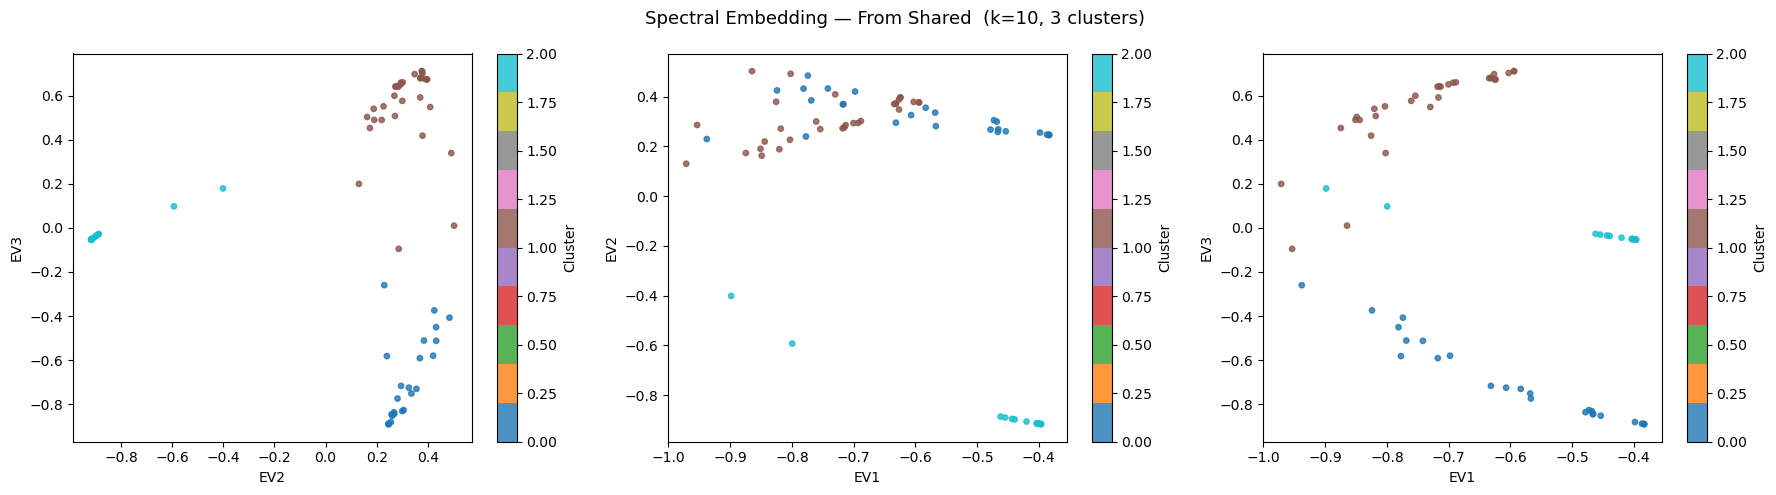

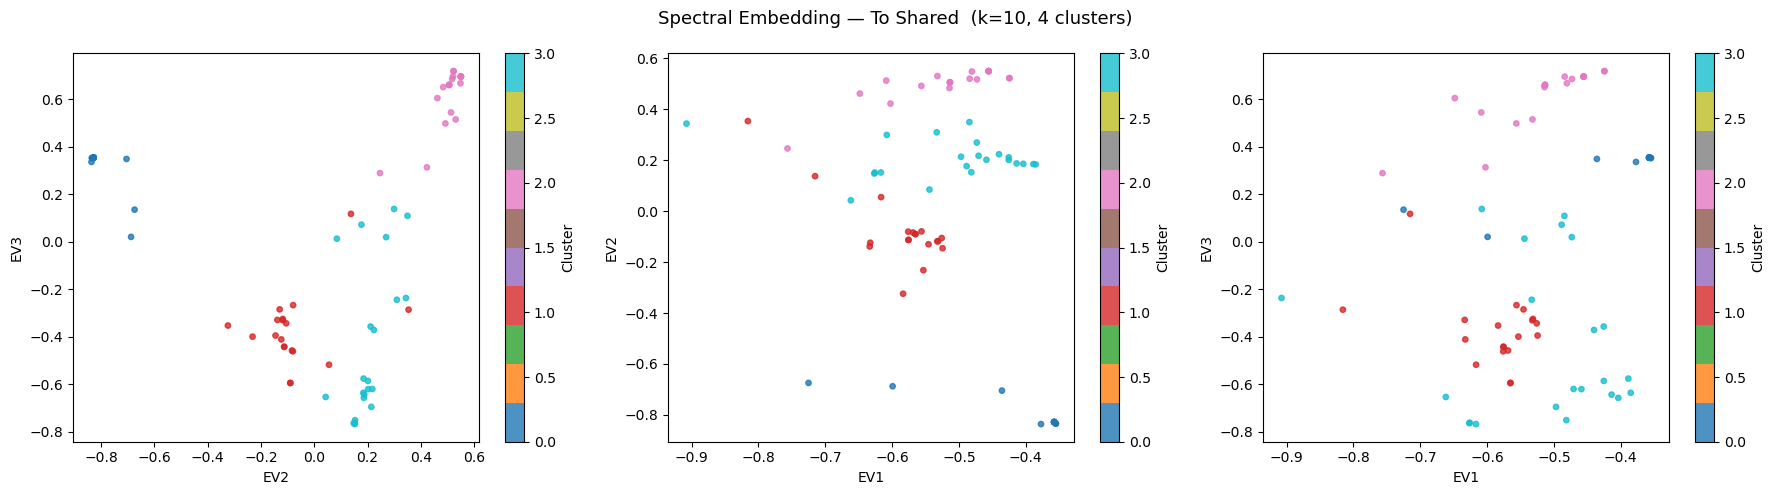

In [43]:
def plot_spectral_embedding(U_norm, labels, title):
    pairs = [(1, 2), (0, 1), (0, 2)]
    pair_labels = [('EV2', 'EV3'), ('EV1', 'EV2'), ('EV1', 'EV3')]
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    for ax, (i, j), (xl, yl) in zip(axes, pairs, pair_labels):
        sc = ax.scatter(U_norm[:, i], U_norm[:, j], c=labels, cmap='tab10', s=15, alpha=0.8)
        ax.set_xlabel(xl)
        ax.set_ylabel(yl)
        plt.colorbar(sc, ax=ax, label='Cluster')
    fig.suptitle(title, fontsize=13)
    plt.tight_layout()
    plt.show()

plot_spectral_embedding(U_from, labels_from,
    f'Spectral Embedding — From Shared  (k={K_NEIGHBORS}, {N_CLUSTERS_EFFERENT} clusters)')
plot_spectral_embedding(U_to, labels_to,
    f'Spectral Embedding — To Shared  (k={K_NEIGHBORS}, {N_CLUSTERS_AFFERENT} clusters)')